<a href="https://colab.research.google.com/github/orcasandpandas/revature_project1/blob/main/Revature_Project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from google.colab import userdata
import os

os.environ["KAGGLE_KEY"] = 'KGAT_6ad84f121952543705b2479aee38ff91'
os.environ["KAGGLE_USERNAME"] = 'JUSTGIVEMEDATAPLS'


In [ ]:
!kaggle datasets download -d agirlcoding/all-space-missions-from-1957


! unzip "all-space-missions-from-1957.zip"


Dataset URL: https://www.kaggle.com/datasets/agirlcoding/all-space-missions-from-1957
License(s): unknown
100% 101k/101k [00:00<00:00, 39.7MB/s]

Archive:  all-space-missions-from-1957.zip
  inflating: Space_Corrected.csv     


In [ ]:
df = pd.read_csv("Space_Corrected.csv")
df

,Unnamed: 0.1,Unnamed: 0,Company Name,Location,Datum,Detail,Status Rocket,Rocket,Status Mission
0,0,0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success
1,1,1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,2,2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success
3,3,3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success
4,4,4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success
...,...,...,...,...,...,...,...,...,...
4319,4319,4319,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA","Wed Feb 05, 1958 07:33 UTC",Vanguard | Vanguard TV3BU,StatusRetired,NaN,Failure
4320,4320,4320,AMBA,"LC-26A, Cape Canaveral AFS, Florida, USA","Sat Feb 01, 1958 03:48 UTC",Juno I | Explorer 1,StatusRetired,NaN,Success
4321,4321,4321,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA","Fri Dec 06, 1957 16:44 UTC",Vanguard | Vanguard TV3,StatusRetired,NaN,Failure
4322,4322,4322,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan","Sun Nov 03, 1957 02:30 UTC",Sputnik 8K71PS | Sputnik-2,StatusRetired,NaN,Success


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4324 entries, 0 to 4323
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Unnamed: 0.1    4324 non-null   int64 
 1   Unnamed: 0      4324 non-null   int64 
 2   Company Name    4324 non-null   object
 3   Location        4324 non-null   object
 4   Datum           4324 non-null   object
 5   Detail          4324 non-null   object
 6   Status Rocket   4324 non-null   object
 7    Rocket         964 non-null    object
 8   Status Mission  4324 non-null   object
dtypes: int64(2), object(7)
memory usage: 304.2+ KB


In [ ]:
df["Status Mission"]

,Status Mission
0,Success
1,Success
2,Success
3,Success
4,Success
...,...
4319,Failure
4320,Success
4321,Failure
4322,Success


In [ ]:
df = df.drop(columns = ["Unnamed: 0.1", "Unnamed: 0"])

In [ ]:
df['Country'] = df['Location'].str.split(',').str[-1].str.strip()
df

,Company Name,Location,Datum,Detail,Status Rocket,Rocket,Status Mission,Country
0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success,USA
1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success,China
2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success,USA
3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success,Kazakhstan
4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success,USA
...,...,...,...,...,...,...,...,...
4319,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA","Wed Feb 05, 1958 07:33 UTC",Vanguard | Vanguard TV3BU,StatusRetired,NaN,Failure,USA
4320,AMBA,"LC-26A, Cape Canaveral AFS, Florida, USA","Sat Feb 01, 1958 03:48 UTC",Juno I | Explorer 1,StatusRetired,NaN,Success,USA
4321,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA","Fri Dec 06, 1957 16:44 UTC",Vanguard | Vanguard TV3,StatusRetired,NaN,Failure,USA
4322,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan","Sun Nov 03, 1957 02:30 UTC",Sputnik 8K71PS | Sputnik-2,StatusRetired,NaN,Success,Kazakhstan


In [ ]:
df["Datum"] = pd.to_datetime(df["Datum"],format="mixed")
df = df.rename(columns = {"Datum": "Date"})
df

/tmp/ipykernel_4937/2562979356.py:1: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df["Datum"] = pd.to_datetime(df["Datum"],format="mixed")


,Company Name,Location,Date,Detail,Status Rocket,Rocket,Status Mission,Country
0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA",2020-08-07 05:12:00+00:00,Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success,USA
1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...",2020-08-06 04:01:00+00:00,Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success,China
2,SpaceX,"Pad A, Boca Chica, Texas, USA",2020-08-04 23:57:00+00:00,Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success,USA
3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan",2020-07-30 21:25:00+00:00,Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success,Kazakhstan
4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA",2020-07-30 11:50:00+00:00,Atlas V 541 | Perseverance,StatusActive,145.0,Success,USA
...,...,...,...,...,...,...,...,...
4319,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA",1958-02-05 07:33:00+00:00,Vanguard | Vanguard TV3BU,StatusRetired,NaN,Failure,USA
4320,AMBA,"LC-26A, Cape Canaveral AFS, Florida, USA",1958-02-01 03:48:00+00:00,Juno I | Explorer 1,StatusRetired,NaN,Success,USA
4321,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA",1957-12-06 16:44:00+00:00,Vanguard | Vanguard TV3,StatusRetired,NaN,Failure,USA
4322,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan",1957-11-03 02:30:00+00:00,Sputnik 8K71PS | Sputnik-2,StatusRetired,NaN,Success,Kazakhstan


In [ ]:
# Drop the `Status Rocket` column
df = df.drop(columns=["Status Rocket"])

#Cleanup the rocket column
#Fix Rocket column name
df = df.rename(columns={" Rocket": "Rocket"})
df

,Company Name,Location,Date,Detail,Rocket,Status Mission,Country
0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA",2020-08-07 05:12:00+00:00,Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,50.0,Success,USA
1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...",2020-08-06 04:01:00+00:00,Long March 2D | Gaofen-9 04 & Q-SAT,29.75,Success,China
2,SpaceX,"Pad A, Boca Chica, Texas, USA",2020-08-04 23:57:00+00:00,Starship Prototype | 150 Meter Hop,NaN,Success,USA
3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan",2020-07-30 21:25:00+00:00,Proton-M/Briz-M | Ekspress-80 & Ekspress-103,65.0,Success,Kazakhstan
4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA",2020-07-30 11:50:00+00:00,Atlas V 541 | Perseverance,145.0,Success,USA
...,...,...,...,...,...,...,...
4319,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA",1958-02-05 07:33:00+00:00,Vanguard | Vanguard TV3BU,NaN,Failure,USA
4320,AMBA,"LC-26A, Cape Canaveral AFS, Florida, USA",1958-02-01 03:48:00+00:00,Juno I | Explorer 1,NaN,Success,USA
4321,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA",1957-12-06 16:44:00+00:00,Vanguard | Vanguard TV3,NaN,Failure,USA
4322,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan",1957-11-03 02:30:00+00:00,Sputnik 8K71PS | Sputnik-2,NaN,Success,Kazakhstan


In [ ]:
# Check which countries are missing values
#df[df["Rocket"].isna()].sort_values("Country")
df.loc[df["Rocket"].isna(), "Country"].dropna().drop_duplicates().tolist()

[]

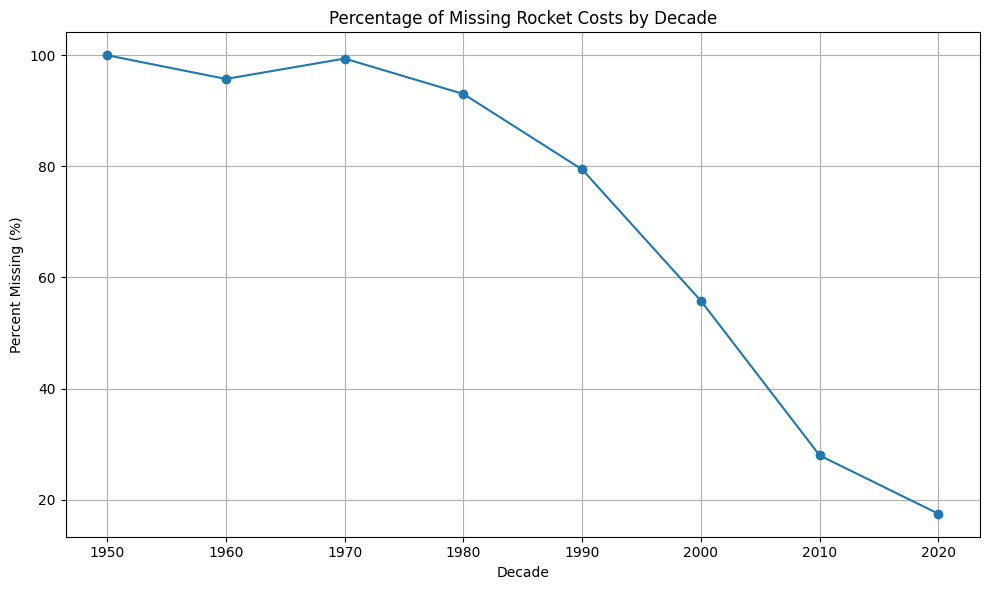

In [ ]:
missing_by_decade = (
    df[df["Rocket"].isna()]
    .groupby(
        (
            pd.to_datetime(
                df.loc[df["Rocket"].isna(), "Date"],
                utc=True
            ).dt.year // 10
        ) * 10
    )
    .size()
    .sort_index()
)

# Count total launches by decade
total_by_decade = (
    df.groupby(
        (
            pd.to_datetime(
                df["Date"],
                utc=True
            ).dt.year // 10
        ) * 10
    )
    .size()
)

# Combine into one table
decade_summary = (
    total_by_decade.to_frame(name="Total Values")
    .join(missing_by_decade.to_frame(name="Missing Values"))
    .fillna(0)
    .astype(int)
)

# Calculate percentage of missing values
decade_summary["Percent Missing"] = (
    decade_summary["Missing Values"] / decade_summary["Total Values"] * 100
)

plt.figure(figsize=(10, 6))

plt.plot(
    decade_summary.index.astype(str),
    decade_summary["Percent Missing"],
    marker="o"
)

plt.xlabel("Decade")
plt.ylabel("Percent Missing (%)")
plt.title("Percentage of Missing Rocket Costs by Decade")

plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Impute missing values for the Rocket column
## Change the `Rocket` column to numeric
df["Rocket"] = pd.to_numeric(df["Rocket"], errors="coerce")
## Calculate median cost of rocket per country and fill in using missing values
country_median = df.groupby("Country")["Rocket"].transform("median")
df["Rocket"] = df["Rocket"].fillna(country_median)

## Repeat process for countries with no median at all
overall_median = df["Rocket"].median()
df["Rocket"] = df["Rocket"].fillna(overall_median)

df

,Company Name,Location,Date,Detail,Rocket,Status Mission,Country
0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA",2020-08-07 05:12:00+00:00,Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,50.00,Success,USA
1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...",2020-08-06 04:01:00+00:00,Long March 2D | Gaofen-9 04 & Q-SAT,29.75,Success,China
2,SpaceX,"Pad A, Boca Chica, Texas, USA",2020-08-04 23:57:00+00:00,Starship Prototype | 150 Meter Hop,109.00,Success,USA
3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan",2020-07-30 21:25:00+00:00,Proton-M/Briz-M | Ekspress-80 & Ekspress-103,65.00,Success,Kazakhstan
4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA",2020-07-30 11:50:00+00:00,Atlas V 541 | Perseverance,145.00,Success,USA
...,...,...,...,...,...,...,...
4319,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA",1958-02-05 07:33:00+00:00,Vanguard | Vanguard TV3BU,109.00,Failure,USA
4320,AMBA,"LC-26A, Cape Canaveral AFS, Florida, USA",1958-02-01 03:48:00+00:00,Juno I | Explorer 1,109.00,Success,USA
4321,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA",1957-12-06 16:44:00+00:00,Vanguard | Vanguard TV3,109.00,Failure,USA
4322,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan",1957-11-03 02:30:00+00:00,Sputnik 8K71PS | Sputnik-2,48.50,Success,Kazakhstan


In [ ]:
df["Country"].unique()

array(['USA', 'China', 'Kazakhstan', 'Japan', 'Israel', 'New Zealand',
       'Russia', 'Shahrud Missile Test Site', 'France', 'Iran', 'India',
       'New Mexico', 'Yellow Sea', 'North Korea',
       'Pacific Missile Range Facility', 'Pacific Ocean', 'South Korea',
       'Barents Sea', 'Brazil', 'Gran Canaria', 'Kenya', 'Australia'],
      dtype=object)

In [ ]:
df["Country"] = df["Country"].replace({"Shahrud Missile Test Site" : "Iran", "Pacific Missile Range Facility" : "USA",
                     "New Mexico" : "USA", "Gran Canaria": "Spain", "Yellow Sea" : "China",
                    "Barents Sea": "Russia", "Pacific Ocean": "Multinational", "Kazakhstan": "Multinational"})

In [ ]:
df["Country"].unique()

array(['USA', 'China', 'Multinational', 'Japan', 'Israel', 'New Zealand',
       'Russia', 'Iran', 'France', 'India', 'North Korea', 'South Korea',
       'Brazil', 'Spain', 'Kenya', 'Australia'], dtype=object)

In [ ]:
df["Rocket"].isnull().sum()

np.int64(0)

In [ ]:
filter = df.loc[df["Country"] == "Australia"]
filter

,Company Name,Location,Date,Detail,Rocket,Status Mission,Country
3302,RAE,"LA-5B, RAAF Woomera Range Complex, Australia",1971-10-28 04:09:00+00:00,Black Arrow | Prospero,48.5,Success,Australia
3413,RAE,"LA-5B, RAAF Woomera Range Complex, Australia",1970-11-02 00:34:00+00:00,Black Arrow | Orba,48.5,Failure,Australia
3462,CECLES,"LA-5B, RAAF Woomera Range Complex, Australia",1970-06-12 06:06:00+00:00,Europa 1 | STV-3,48.5,Failure,Australia
3548,CECLES,"LA-5B, RAAF Woomera Range Complex, Australia",1969-07-03 08:06:00+00:00,Europa 1 | STV-2,48.5,Failure,Australia
3613,CECLES,"LA-5B, RAAF Woomera Range Complex, Australia",1968-11-29 09:47:00+00:00,Europa 1 | STV-1,48.5,Success,Australia
3711,AMBA,"LA-5B, RAAF Woomera Range Complex, Australia",1967-11-29 00:00:00,Redstone Sparta | WRESAT,48.5,Success,Australia


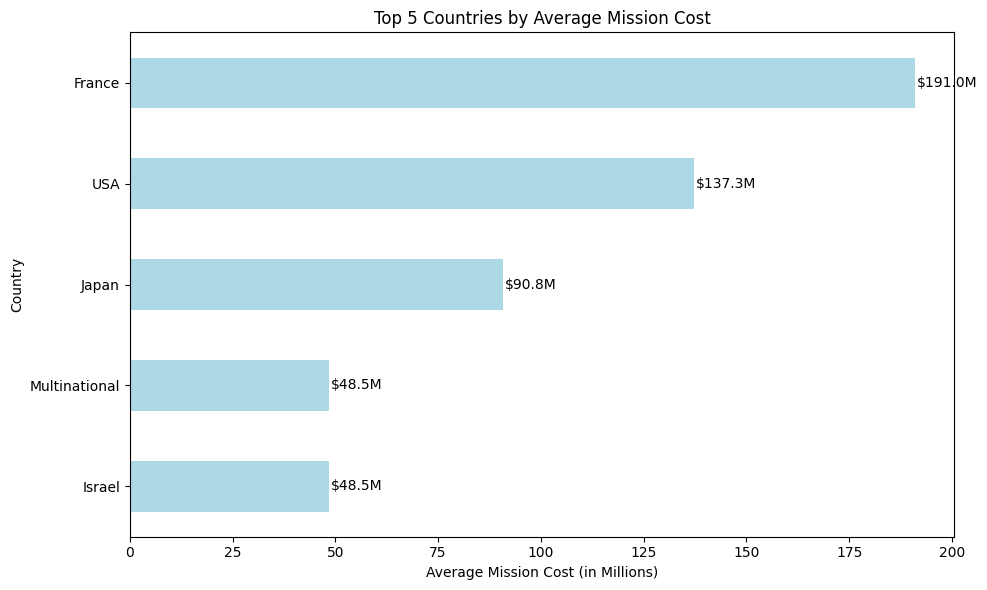

In [ ]:
# TOP 5 COUNTRIES IN TERMS OF AVERAGE COST

# Calculate average cost per country
country_avg = (
    df.groupby("Country")["Rocket"]
    .mean()
    .sort_values(ascending=False)
    .rename("Average Mission Cost")
)

# Get top 5 countries by average cost
top5 = country_avg.head(5)

# Create plot
fig, ax = plt.subplots(figsize=(10, 6))
top5.sort_values().plot(kind="barh", ax=ax, color="LightBlue")

ax.set_title("Top 5 Countries by Average Mission Cost")
ax.set_xlabel("Average Mission Cost (in Millions)")
ax.set_ylabel("Country")

# Add $ labels to the plot
for i, value in enumerate(top5.sort_values()):
    ax.text(value + 0.5, i, f"${value:.1f}M", va="center")

plt.tight_layout()
plt.show()

In [ ]:
# TOP 10 COMPANIES BY MISSION SUCCESS RATE

# calculate total launches per company
company_total = df.groupby("Company Name").size()

# calculate successful launches per company
company_success = (
    df[df["Status Mission"] == "Success"]
    .groupby("Company Name")
    .size()
)

# calculate success rate percentage
success_rate = (company_success / company_total * 100).fillna(0)


# get top 10 companies by success rate
top10 = qualified_companies.sort_values(ascending=False).head(10)

# make plot
plt.figure(figsize=(10, 6))

ax = top10.sort_values().plot(kind="barh")

plt.title("Top 10 Companies by Mission Success Rate")
plt.xlabel("Success Rate (%)")
plt.ylabel("Company")
plt.xlim(85, 100)

# add % labels to bars
for i, value in enumerate(top10.sort_values()):
    plt.text(value + 0.1, i, f"{value:.1f}%", va="center")

plt.tight_layout()
plt.show()

NameError: name 'qualified_companies' is not defined